# Playground Series Season 6 Episode 2: Heart Disease Prediction - EDA

This script is designed to be run as an interactive Python script (using VS Code's Jupyter extension or Jupytext).
Cells are marked with `# %%`.

**Goal:** Understand the data distribution, check for missing values, and identify potential features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 1. Load Data
We'll load the train and test datasets.

In [4]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Train Shape: (630000, 15)
Test Shape: (270000, 14)


## 2. Basic Inspection
Let's look at the first few rows, data types, and missing values.

In [12]:
print("--- Train Head ---")
display(train_df.head())

print("\n--- Train Info ---")
train_df.info()

print("\n--- Missing Values (Train) ---")
missing_train = train_df.isnull().sum()
missing_train_pct = (missing_train / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_train,
    'Missing %': missing_train_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("No missing values found in train set!")

print("\n--- Zero Values (Train) ---")
# Check for columns with zeros (excluding 'id')
zero_counts = (train_df.drop(columns=['id'], errors='ignore') == 0).sum()
zero_pct = (zero_counts / len(train_df) * 100).round(2)
zero_df = pd.DataFrame({
    'Zero Count': zero_counts,
    'Zero %': zero_pct
})
zero_df = zero_df[zero_df['Zero Count'] > 0].sort_values('Zero Count', ascending=False)

if len(zero_df) > 0:
    display(zero_df)
else:
    print("No zero values found!")

--- Train Head ---


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence



--- Train Info ---
<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  


,Zero Count,Zero %
FBS over 120,579608,92.00
Exercise angina,457553,72.63
Number of vessels fluro,445862,70.77
EKG results,320116,50.81
ST depression,314939,49.99
Sex,179717,28.53


## 3. Target Distribution
Is the target balanced or imbalanced?

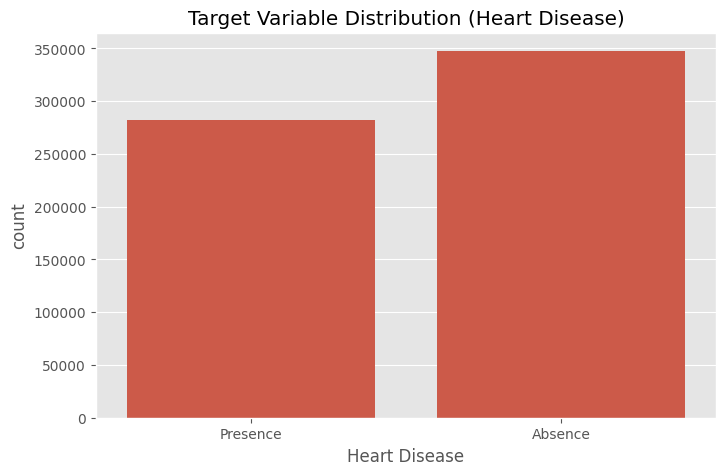

Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64


In [6]:
target_col = 'Heart Disease'

plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x=target_col)
plt.title('Target Variable Distribution (Heart Disease)')
plt.show()

print(train_df[target_col].value_counts(normalize=True))

## 4. Numerical Features Distribution
Let's look at the distribution of numerical features.

In [7]:
features = [col for col in train_df.columns if col not in ['id', target_col]]
num_features = train_df[features].select_dtypes(include=[np.number]).columns.tolist()

print(f"Numerical Features: {len(num_features)}")
print(num_features)

Numerical Features: 13
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


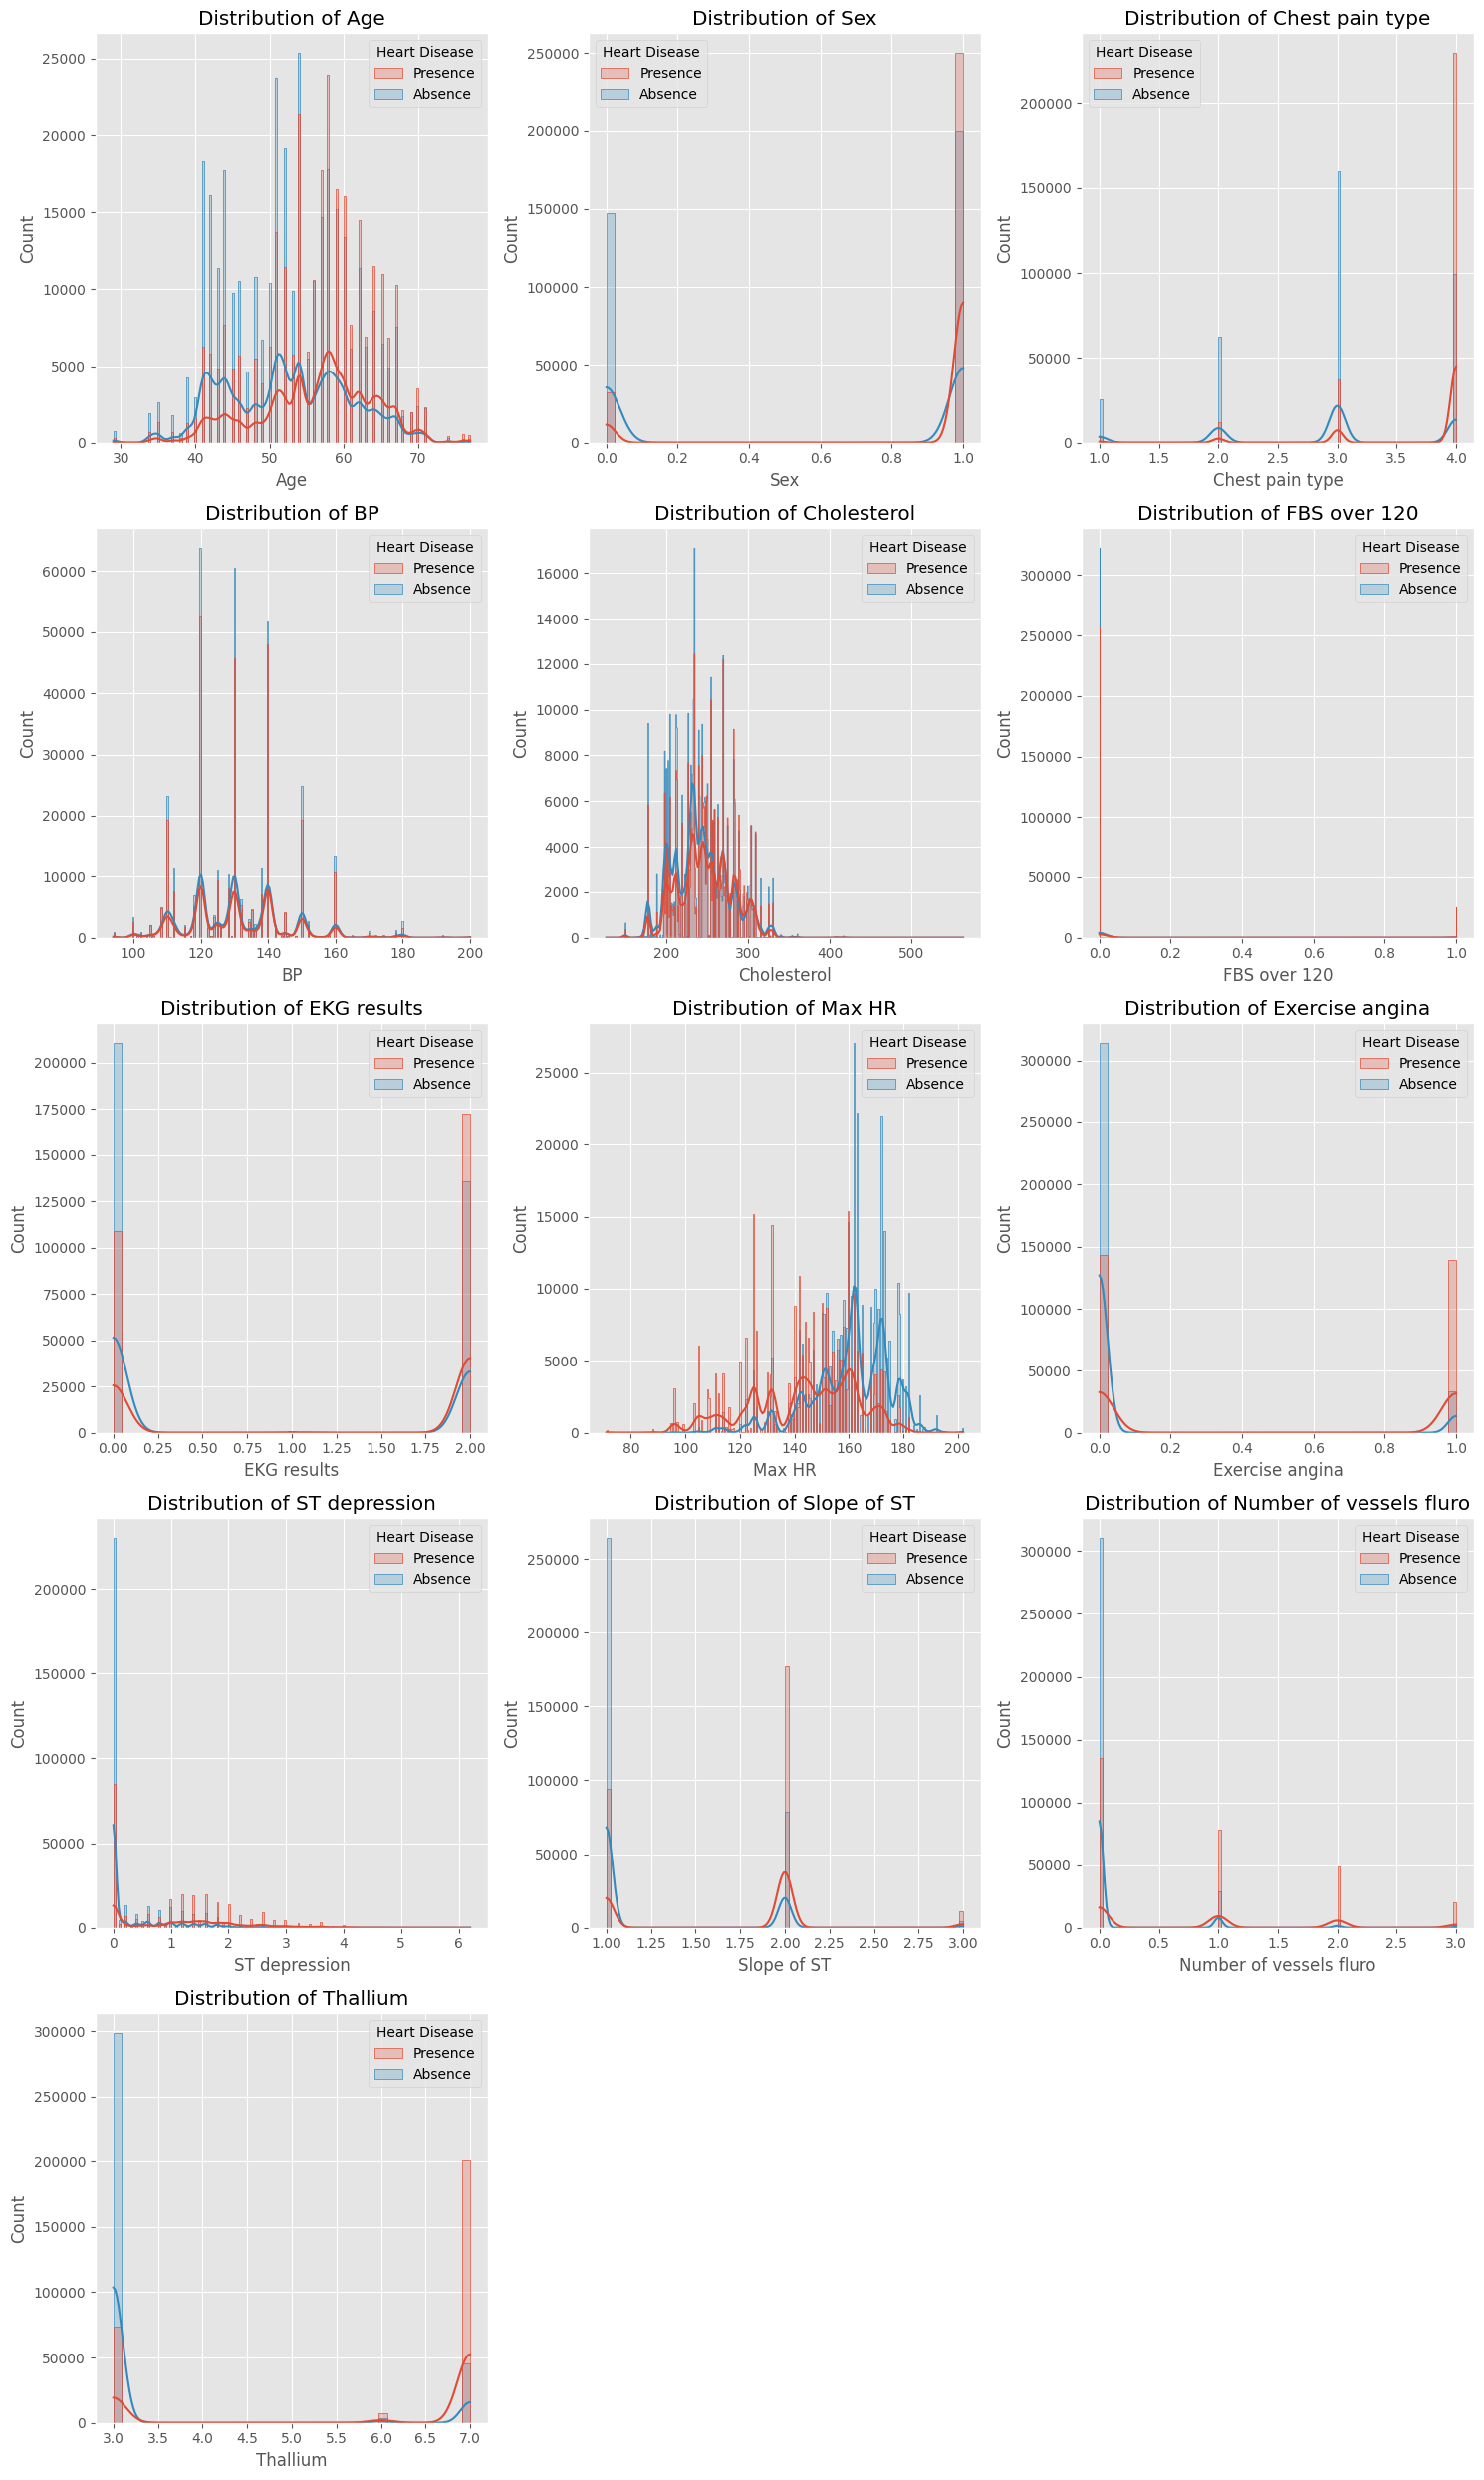

In [8]:
# Histograms for numerical features
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=train_df, x=col, hue=target_col, kde=True, element="step", ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Hide empty subplots
for i in range(len(num_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 5. Correlation Matrix
Check for linear relationships between features and target.

Columns used for correlation: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


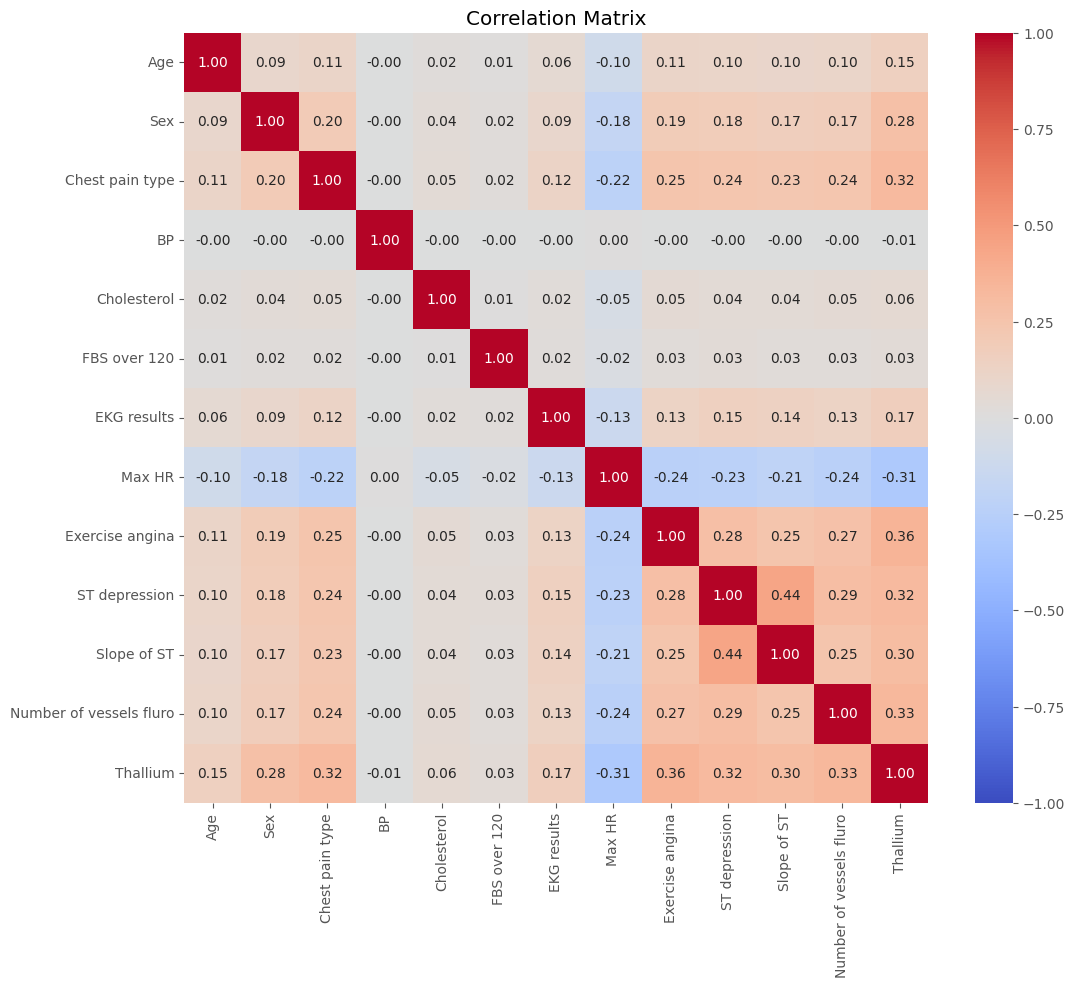

In [11]:
# Encode target for correlation if needed
if train_df[target_col].dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    train_df['Heart Disease_encoded'] = le.fit_transform(train_df[target_col])
    print(f"Encoded {target_col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Select ONLY numeric columns (this will exclude the original 'Heart Disease' string column)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove 'id' column if present
if 'id' in numeric_cols:
    numeric_cols.remove('id')

print(f"Columns used for correlation: {numeric_cols}")

corr_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

## 6. Categorical Features
Check unique values for categorical columns (including numeric ones that represent categories).

Categorical-like Features: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium']


--- Sex ---
Sex
0    179717
1    450283
Name: count, dtype: int64


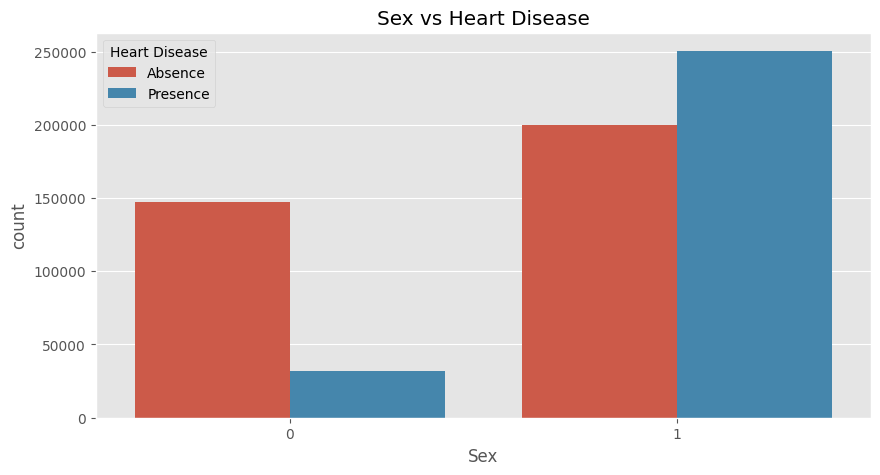


--- Chest pain type ---
Chest pain type
1     28602
2     74941
3    197278
4    329179
Name: count, dtype: int64


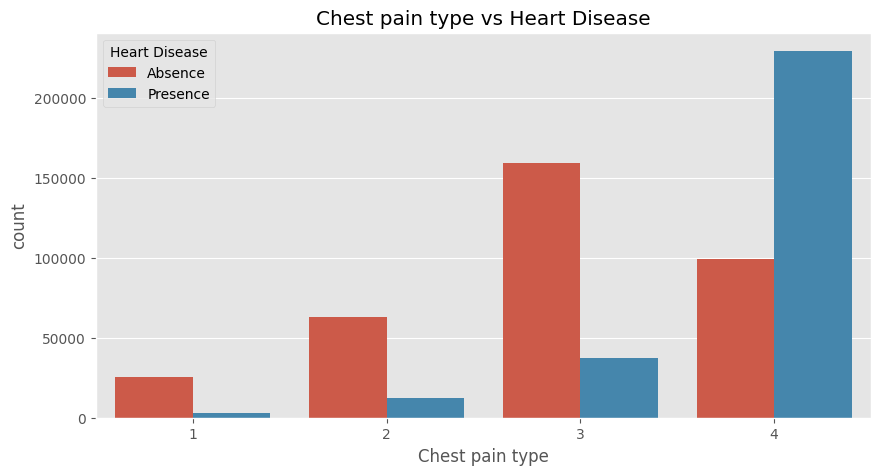


--- FBS over 120 ---
FBS over 120
0    579608
1     50392
Name: count, dtype: int64


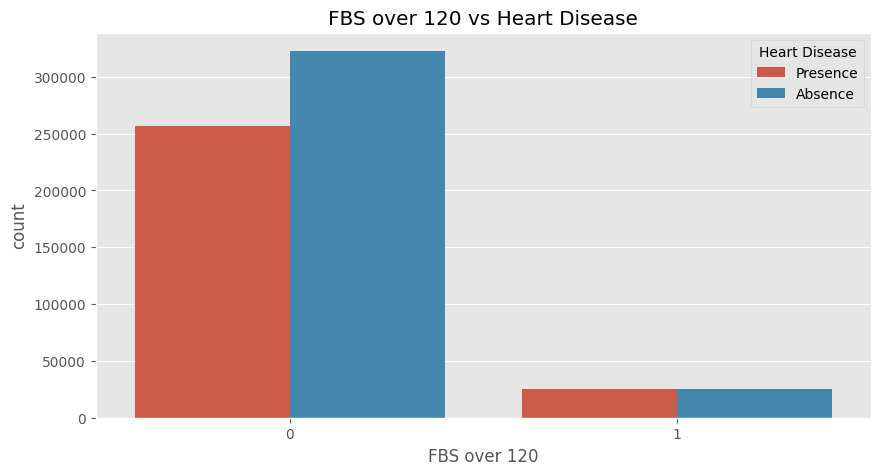


--- EKG results ---
EKG results
0    320116
1      1322
2    308562
Name: count, dtype: int64


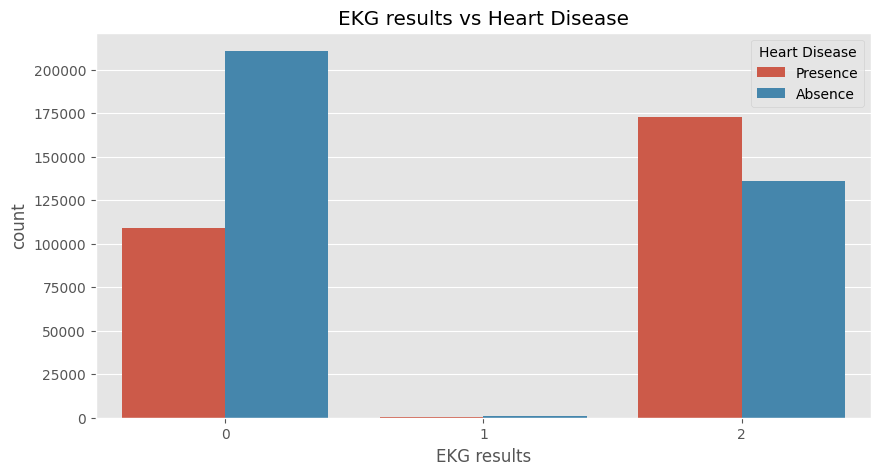


--- Exercise angina ---
Exercise angina
0    457553
1    172447
Name: count, dtype: int64


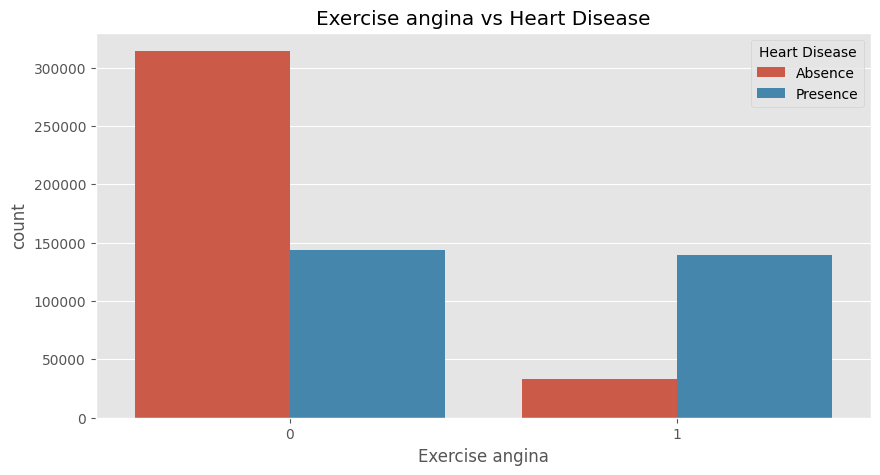


--- Slope of ST ---
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64


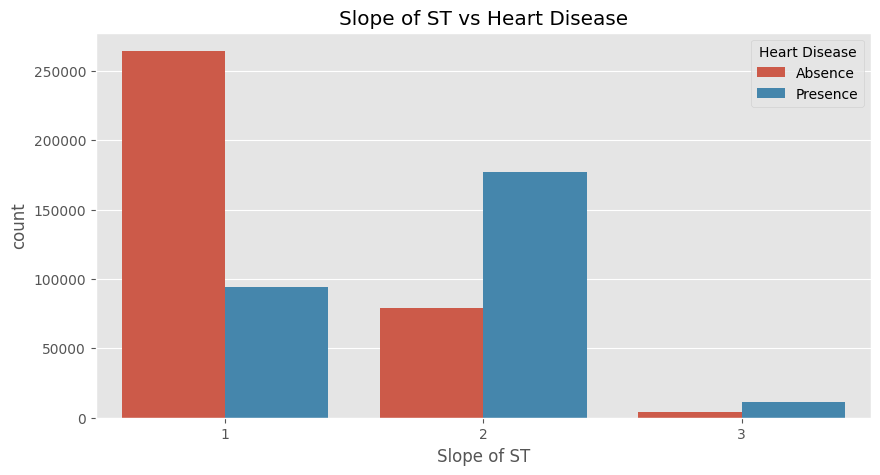


--- Thallium ---
Thallium
3    372286
6     10966
7    246748
Name: count, dtype: int64


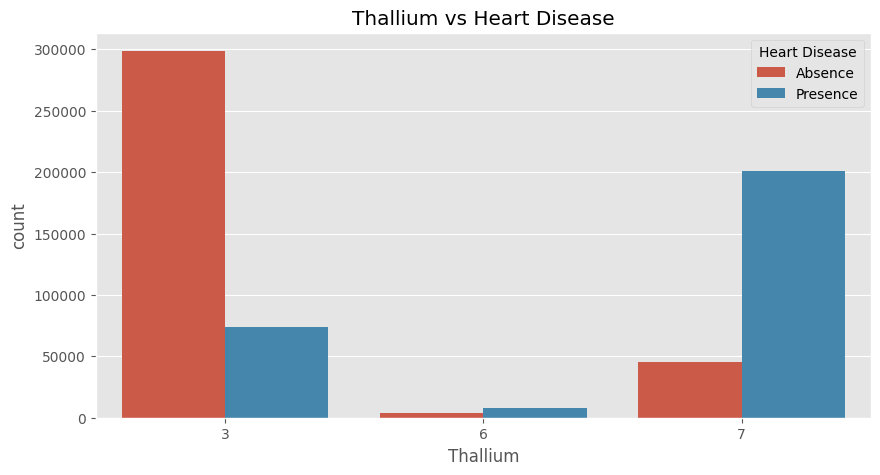

In [ ]:
# Numeric columns that are actually categorical
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                        'Exercise angina', 'Slope of ST', 'Thallium']

print(f"Categorical-like Features: {categorical_features}\n")

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(train_df[col].value_counts().sort_index())
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=train_df, x=col, hue=target_col)
    plt.title(f'{col} vs {target_col}')
    plt.xticks(rotation=0)
    plt.show()

New features created:
['RPP', 'Electrical_Stress', 'Metabolic_Score', 'MaxHR_Rel_Age']


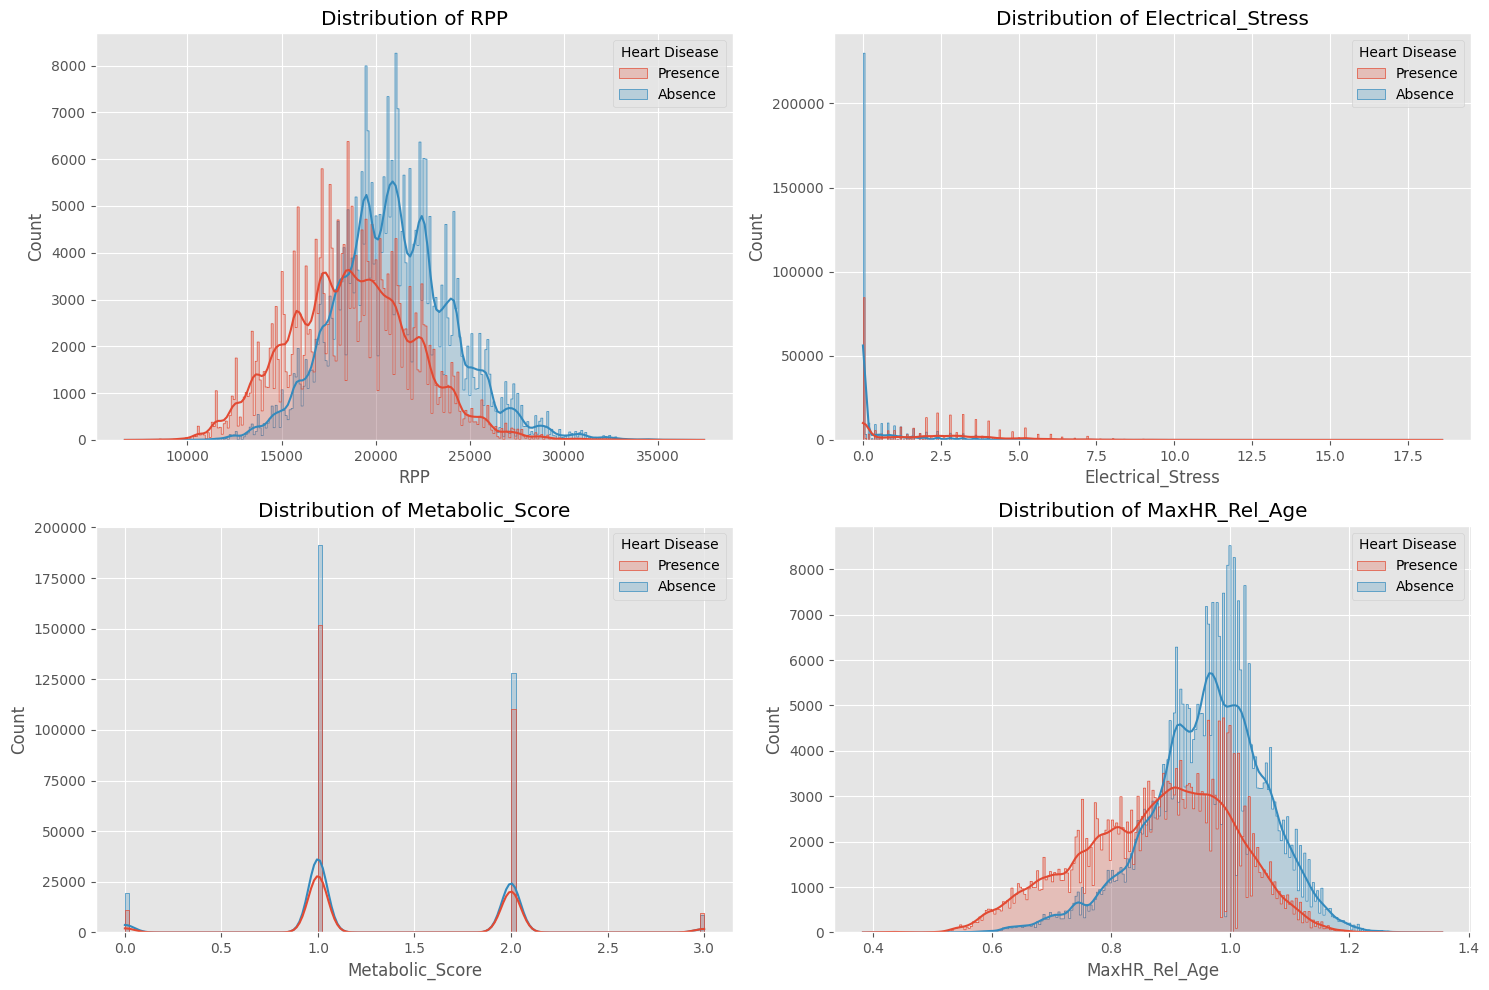


--- Correlation with Target ---
Electrical_Stress    0.442244
Metabolic_Score      0.044242
RPP                 -0.326279
MaxHR_Rel_Age       -0.343383
Name: Heart Disease_encoded, dtype: float64


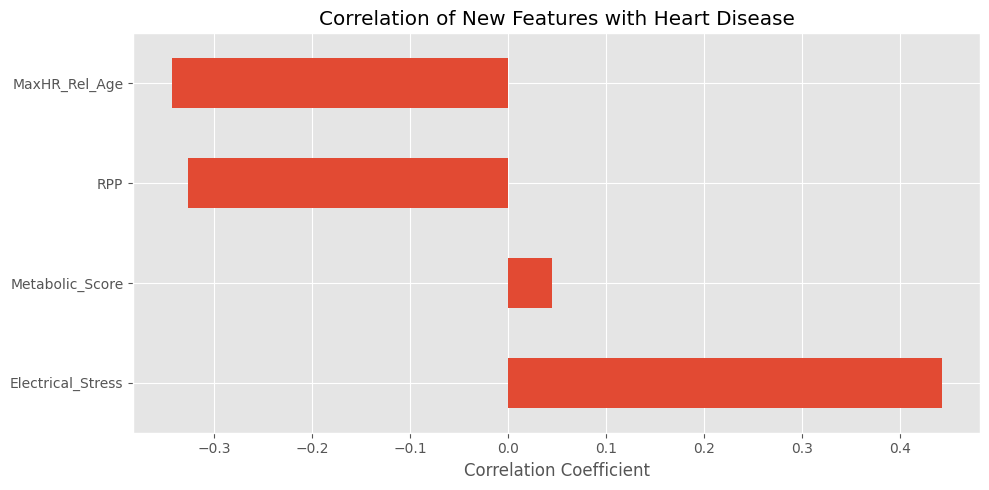

In [14]:
# %% [markdown]
# ## 7. Feature Engineering
# Create new features based on domain knowledge and feature interactions.

# %%
# Rate Pressure Product (心筋酸素消費量の指標)
train_df['RPP'] = train_df['BP'] * train_df['Max HR']

# Electrical Stress (ST depression × Slope)
# Note: このデータセットには 'Slope of ST' が数値で入っているので、そのまま使用
train_df['Electrical_Stress'] = train_df['ST depression'] * train_df['Slope of ST']

# Metabolic Score (代謝リスクスコア)
train_df['Metabolic_Score'] = (train_df['BP'] > 130).astype(int) + \
                               (train_df['Cholesterol'] > 200).astype(int) + \
                               (train_df['FBS over 120'] == 1).astype(int)

# MaxHR relative to age (年齢に対する最大心拍数の割合)
train_df['MaxHR_Rel_Age'] = train_df['Max HR'] / (220 - train_df['Age'])

print("New features created:")
new_features = ['RPP', 'Electrical_Stress', 'Metabolic_Score', 'MaxHR_Rel_Age']
print(new_features)

# %%
# Distribution of new features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    sns.histplot(data=train_df, x=col, hue=target_col, kde=True, element="step", ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# %%
# Correlation of new features with target
print("\n--- Correlation with Target ---")
train_df_with_encoded = train_df.copy()
if 'Heart Disease_encoded' not in train_df_with_encoded.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    train_df_with_encoded['Heart Disease_encoded'] = le.fit_transform(train_df[target_col])

correlations = train_df_with_encoded[new_features + ['Heart Disease_encoded']].corr()['Heart Disease_encoded'].drop('Heart Disease_encoded').sort_values(ascending=False)
print(correlations)

plt.figure(figsize=(10, 5))
correlations.plot(kind='barh')
plt.title('Correlation of New Features with Heart Disease')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()